MAKİNE ÖĞRENMESİ YÖNTEMLERİYLE KREDİ ONAY TAHMİNİ
-Yavuz Selim Kaya
-Sefer Ağca

-- GEREKLİ KÜTÜPHANELERİN YÜKLENMESİ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, roc_auc_score, 
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve)

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


from imblearn.over_sampling import SMOTE
import shap

#Uyarıları görmezden gelme
import warnings
warnings.filterwarnings('ignore')
print("Kutuphaneler yuklendi")

Kutuphaneler yuklendi


VERİ SETİNİN YÜKLENMESİ VE EKSİK VERİLERİN TAMAMLANMASI

In [2]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"
columns = ["A1","A2","A3","A4","A5","A6","A7","A8","A9","A10","A11","A12","A13","A14","A15","Target"]
df = pd.read_csv(url, names=columns, header=None)


df = df.replace('?', np.nan)
df[['A2', 'A14']] = df[['A2', 'A14']].astype(float)

print("VERİ SETİ BOYUTU")
print(f"Satır: {df.shape[0]}, Sütun: {df.shape[1]}\n")

print("VERİ TİPLERİ VE EKSİK VERİ SAYILARI")
display(df.info())

print("\nSAYISAL VERİLERİN İSTATİSTİKSEL ÖZETİ")
display(df.describe().T)

VERİ SETİ BOYUTU
Satır: 690, Sütun: 16

VERİ TİPLERİ VE EKSİK VERİ SAYILARI
<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    str    
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    str    
 4   A5      684 non-null    str    
 5   A6      681 non-null    str    
 6   A7      681 non-null    str    
 7   A8      690 non-null    float64
 8   A9      690 non-null    str    
 9   A10     690 non-null    str    
 10  A11     690 non-null    int64  
 11  A12     690 non-null    str    
 12  A13     690 non-null    str    
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  Target  690 non-null    str    
dtypes: float64(4), int64(2), str(10)
memory usage: 86.4 KB


None


SAYISAL VERİLERİN İSTATİSTİKSEL ÖZETİ


,count,mean,std,min,25%,50%,75%,max
A2,678.0,31.568171,11.957862,13.75,22.6025,28.46,38.2300,80.25
A3,690.0,4.758725,4.978163,0.00,1.0000,2.75,7.2075,28.00
A8,690.0,2.223406,3.346513,0.00,0.1650,1.00,2.6250,28.50
A11,690.0,2.400000,4.862940,0.00,0.0000,0.00,3.0000,67.00
A14,677.0,184.014771,173.806768,0.00,75.0000,160.00,276.0000,2000.00
A15,690.0,1017.385507,5210.102598,0.00,0.0000,5.00,395.5000,100000.00


EKSİK VERİLERİN TAMAMLANMASI VE GÖRSELLEŞTİRME

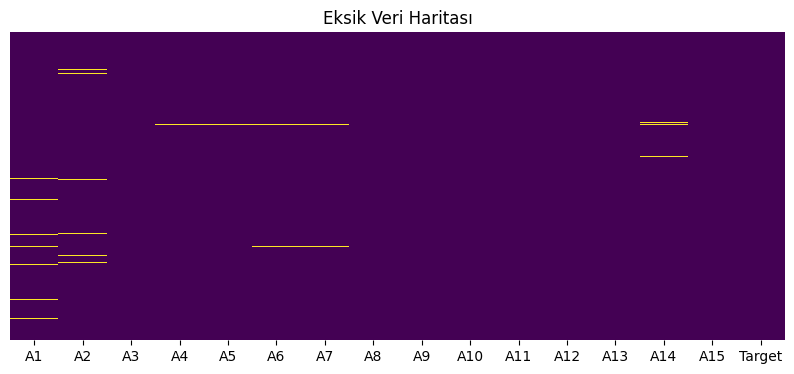

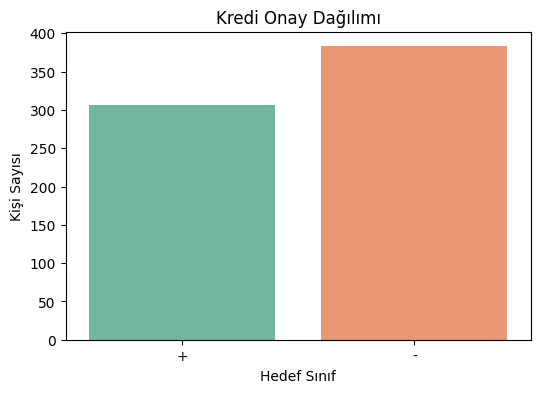

Hedef Sınıf Oranları
Target
-    55.507246
+    44.492754
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Eksik Veri Haritası")
plt.show()


plt.figure(figsize=(6, 4))
sns.countplot(x='Target', data=df, palette='Set2')
plt.title("Kredi Onay Dağılımı")
plt.xlabel("Hedef Sınıf")
plt.ylabel("Kişi Sayısı")
plt.show()

print("Hedef Sınıf Oranları")
print(df['Target'].value_counts(normalize=True) * 100)

PREPROCESSING VE KATEGORİK VERİLERİN SAYISALLAŞTIRILMASI
Veri Ölçekleme ce Eğitim ve Test verisetlerinin ayrılması 

In [4]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].mean()) # Sayısallar ortalama ile
    else:
        df[col] = df[col].fillna(df[col].mode()[0]) # Kategorikler mod ile

le = LabelEncoder()
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop('Target', axis=1)
y = df['Target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.20, random_state=42)
print("Veri temizlendi, sayısallaştırıldı ve ölçeklendirildi.")

Veri temizlendi, sayısallaştırıldı ve ölçeklendirildi.


KORELASYON MATRİSİNİN OLUŞTURULMASI

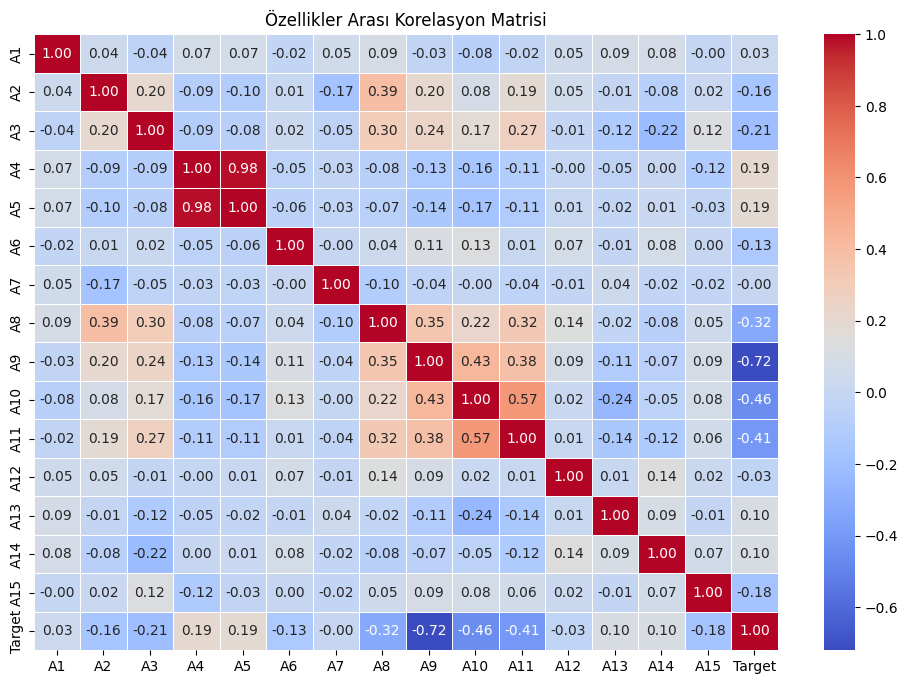

In [5]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Özellikler Arası Korelasyon Matrisi")
plt.show()

SMOTE İLE VERİSETLERİNİN DENGELENMESİ

SMOTE Öncesi Sınıf Dağılımı:
 Target
1    315
0    237
Name: count, dtype: int64

SMOTE Sonrası Sınıf Dağılımı:
 Target
1    315
0    315
Name: count, dtype: int64


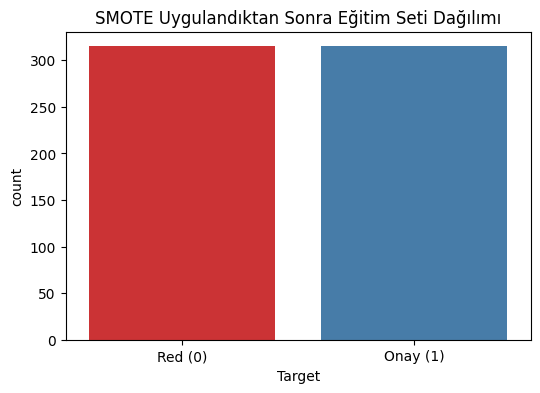

In [6]:
# SMOTE İLE VERİ ARTIRIMI
print("SMOTE Öncesi Sınıf Dağılımı:\n", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nSMOTE Sonrası Sınıf Dağılımı:\n", y_train_resampled.value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled, palette='Set1')
plt.title("SMOTE Uygulandıktan Sonra Eğitim Seti Dağılımı")
plt.xticks([0, 1], ['Red (0)', 'Onay (1)'])
plt.show()

In [7]:
# MODEL TANIMLAMALARI
# Stacking için Taban Modeller
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('nb', GaussianNB())
]

# Stacking Meta-Model
meta_model = LogisticRegression(random_state=42)
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)

# Tüm modelleri tek bir sözlükte topluyoruz
models = {
    "Karar Ağacı": DecisionTreeClassifier(random_state=42),
    "K-En Yakın Komşu": KNeighborsClassifier(n_neighbors=5),
    "Rastgele Orman": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "Önerilen Hibrit Model (Stacking)": stacking_clf
}
print("Hücre 7 Tamamlandı: Klasik, Gelişmiş ve Hibrit modeller tanımlandı.")

Hücre 7 Tamamlandı: Klasik, Gelişmiş ve Hibrit modeller tanımlandı.


In [8]:
#EĞİTİM VE METRİKLER
print("--- MODEL PERFORMANS SONUÇLARI ---\n")

for name, model in models.items():
    # Modeli SMOTE'lu veriyle eğit
    model.fit(X_train_resampled, y_train_resampled)
    
    # Tahmin yap
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else [0]*len(y_test)
    
    # Skorkarı hesapla
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    print(f"Model: {name}")
    print(f"Doğruluk (Accuracy): {acc:.4f} | ROC-AUC Skoru: {roc_auc:.4f}\n")
    
print("Hücre 8 Tamamlandı. (Sonuçları raporunuzdaki Tablo 1'e ekleyebilirsiniz.)")

MODEL PERFORMANS SONUÇLARI 

Model: Karar Ağacı
Doğruluk (Accuracy): 0.7899 | ROC-AUC Skoru: 0.7901

Model: K-En Yakın Komşu
Doğruluk (Accuracy): 0.8333 | ROC-AUC Skoru: 0.8634

Model: Rastgele Orman
Doğruluk (Accuracy): 0.8623 | ROC-AUC Skoru: 0.9155

Model: XGBoost
Doğruluk (Accuracy): 0.8333 | ROC-AUC Skoru: 0.9048

Model: LightGBM
Doğruluk (Accuracy): 0.8406 | ROC-AUC Skoru: 0.9088

Model: Önerilen Hibrit Model (Stacking)
Doğruluk (Accuracy): 0.8696 | ROC-AUC Skoru: 0.9034



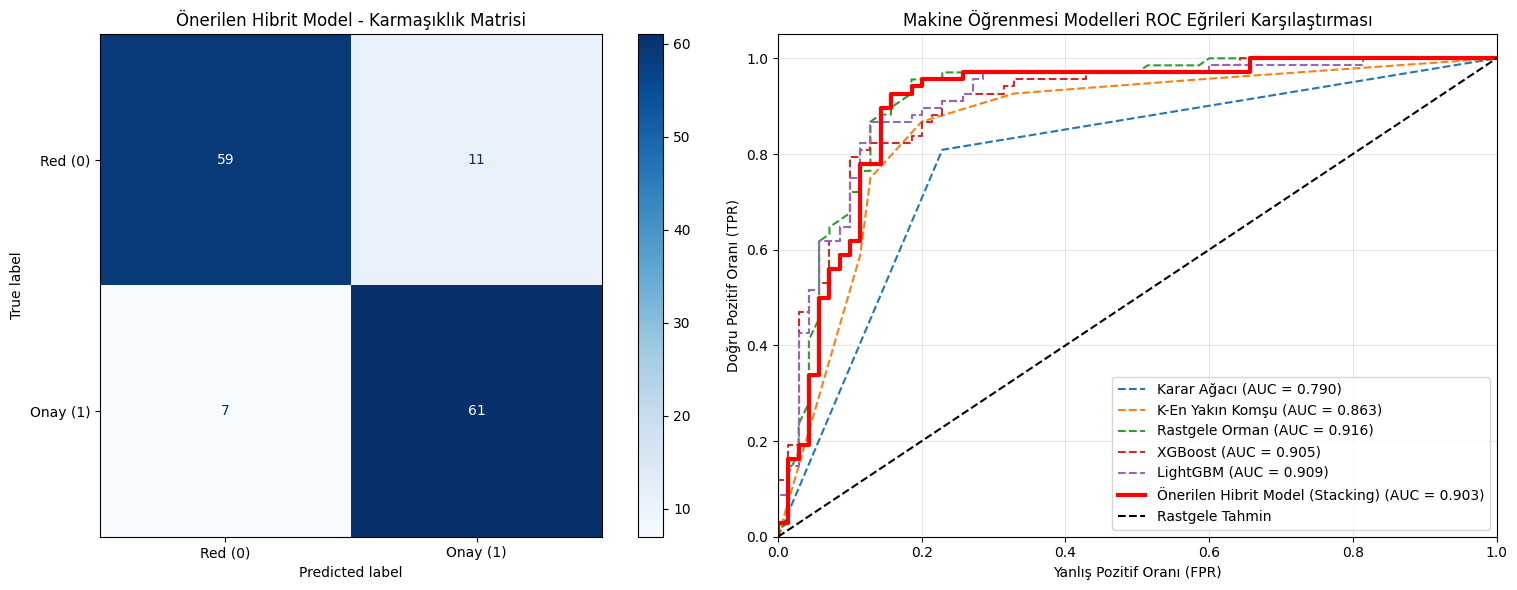

In [9]:
# HÜCRE 9: PERFORMANS GÖRSELLEŞTİRMELERİ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Karmaşıklık Matrisi (Hibrit Model için)
y_pred_stack = models["Önerilen Hibrit Model (Stacking)"].predict(X_test)
cm = confusion_matrix(y_test, y_pred_stack)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Red (0)', 'Onay (1)'])
disp.plot(cmap='Blues', values_format='d', ax=axes[0])
axes[0].set_title("Önerilen Hibrit Model - Karmaşıklık Matrisi")

# 2. ROC Eğrisi
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)
        
        if name == "Önerilen Hibrit Model (Stacking)":
            axes[1].plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=3, color='red')
        else:
            axes[1].plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linestyle='--')

axes[1].plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Yanlış Pozitif Oranı (FPR)')
axes[1].set_ylabel('Doğru Pozitif Oranı (TPR)')
axes[1].set_title('Makine Öğrenmesi Modelleri ROC Eğrileri Karşılaştırması')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# HÜCRE 10: K-KATLAMALI ÇAPRAZ DOĞRULAMA
print("--- 10-KATLAMALI ÇAPRAZ DOĞRULAMA (HIBRİT MODEL) ---\n")
cv_scores = cross_val_score(stacking_clf, X_train_resampled, y_train_resampled, cv=10, scoring='accuracy')

print(f"Her bir katmandaki doğruluk oranları:\n{np.round(cv_scores, 4)}\n")
print(f"Ortalama CV Doğruluğu: {cv_scores.mean():.4f}")
print(f"Standart Sapma (+/-):  {cv_scores.std():.4f}")

10-KATLAMALI ÇAPRAZ DOĞRULAMA (HIBRİT MODEL) 

Her bir katmandaki doğruluk oranları:
[0.9365 0.9048 0.9048 0.8413 0.9048 0.8413 0.9206 0.873  0.9048 0.9048]

Ortalama CV Doğruluğu: 0.8937
Standart Sapma (+/-):  0.0302


--- YSA (YAPAY SİNİR AĞLARI) MODELİ EĞİTİLİYOR ---

YSA Modeli Doğruluk (Accuracy): 0.7899
YSA Modeli ROC-AUC Skoru:       0.8481



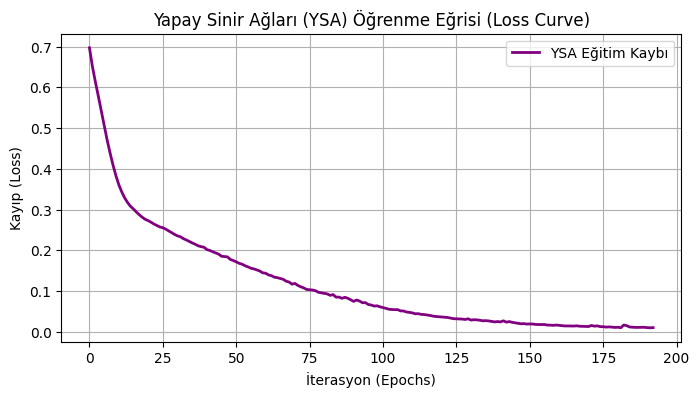

In [11]:
# HÜCRE 11: YAPAY SİNİR AĞLARI (YSA / MLP)
print("--- YSA (YAPAY SİNİR AĞLARI) MODELİ EĞİTİLİYOR ---\n")
ysa_model = MLPClassifier(hidden_layer_sizes=(100, 50, 25), activation='relu', solver='adam', max_iter=500, random_state=42)
ysa_model.fit(X_train_resampled, y_train_resampled)

ysa_acc = accuracy_score(y_test, ysa_model.predict(X_test))
ysa_roc_auc = roc_auc_score(y_test, ysa_model.predict_proba(X_test)[:, 1])

print(f"YSA Modeli Doğruluk (Accuracy): {ysa_acc:.4f}")
print(f"YSA Modeli ROC-AUC Skoru:       {ysa_roc_auc:.4f}\n")

plt.figure(figsize=(8, 4))
plt.plot(ysa_model.loss_curve_, label='YSA Eğitim Kaybı', color='purple', linewidth=2)
plt.title('Yapay Sinir Ağları (YSA) Öğrenme Eğrisi (Loss Curve)')
plt.xlabel('İterasyon (Epochs)')
plt.ylabel('Kayıp (Loss)')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
# HÜCRE 12: HYPERPARAMETER OPTIMIZATION
print("--- HİPERPARAMETRE OPTİMİZASYONU (GRID SEARCH CV) ---")
print("Rastgele Orman için en iyi parametreler aranıyor...\n")

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_resampled, y_train_resampled)

print(f"Bulunan En İyi Parametreler: {grid_search.best_params_}")
print(f"Optimize Edilmiş Modelin Doğruluğu: {grid_search.best_score_:.4f}")

--- HİPERPARAMETRE OPTİMİZASYONU (GRID SEARCH CV) ---
Rastgele Orman için en iyi parametreler aranıyor...

Bulunan En İyi Parametreler: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Optimize Edilmiş Modelin Doğruluğu: 0.8968


Finansal Risk Yönetimi İçin Bulunan En İdeal Eşik Değer: 0.4257



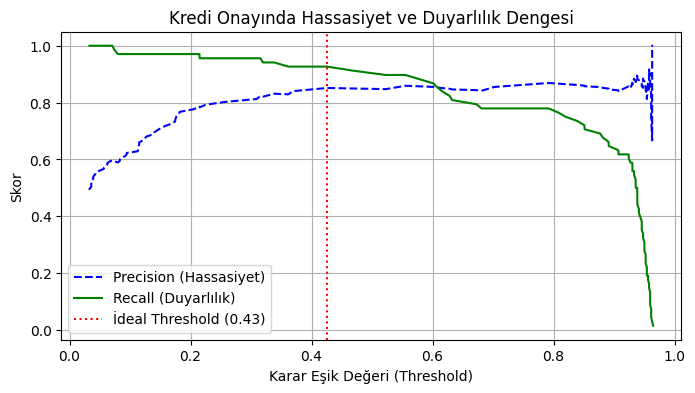

In [13]:
# HÜCRE 13: PRECISION-RECALL VE THRESHOLD
y_prob_hybrid = stacking_clf.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_hybrid)

f1_scores = 2 * (precision * recall) / (precision + recall)
f1_scores = np.nan_to_num(f1_scores)
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print(f"Finansal Risk Yönetimi İçin Bulunan En İdeal Eşik Değer: {best_threshold:.4f}\n")

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision (Hassasiyet)')
plt.plot(thresholds, recall[:-1], 'g-', label='Recall (Duyarlılık)')
plt.axvline(x=best_threshold, color='red', linestyle=':', label=f'İdeal Threshold ({best_threshold:.2f})')
plt.xlabel('Karar Eşik Değeri (Threshold)')
plt.ylabel('Skor')
plt.title('Kredi Onayında Hassasiyet ve Duyarlılık Dengesi')
plt.legend()
plt.grid(True)
plt.show()

SHAP Değerleri Hesaplanıyor... (Bu işlem birkaç saniye sürebilir)



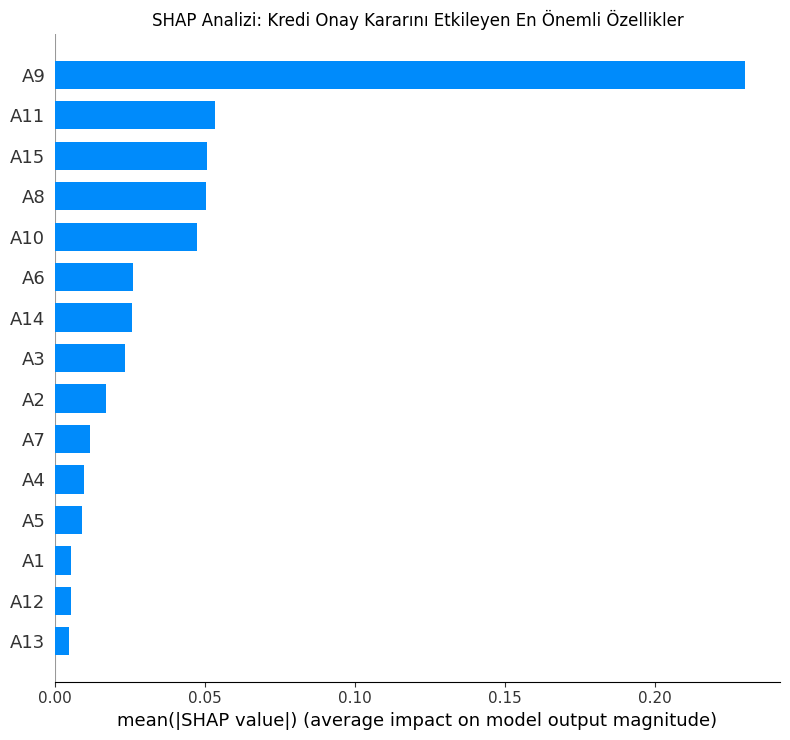

PROJE BAŞARIYLA TAMAMLANDI!


In [14]:
# HÜCRE 14: SHAP (AÇIKLANABİLİR YAPAY ZEKA)
print("SHAP Değerleri Hesaplanıyor... (Bu işlem birkaç saniye sürebilir)\n")

rf_model_for_shap = RandomForestClassifier(random_state=42).fit(X_train_resampled, y_train_resampled)
explainer = shap.TreeExplainer(rf_model_for_shap)
shap_values = explainer.shap_values(X_test)

# SHAP Kütüphanesi Versiyon Çözücü
if isinstance(shap_values, list):
    shap_vals_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_vals_to_plot = shap_values[:, :, 1]
else:
    shap_vals_to_plot = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_to_plot, X_test, feature_names=X.columns, plot_type="bar", show=False)
plt.title("SHAP Analizi: Kredi Onay Kararını Etkileyen En Önemli Özellikler")
plt.tight_layout()
plt.show()
print("PROJE BAŞARIYLA TAMAMLANDI!")